In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv(r"C:\Users\PRATIBHA\Desktop\data\q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


Scaling is important because all features have different units. For example, age may be small (like 25), but annual spend may be large (like 50000). K-Means uses distance, so bigger numbers will dominate. Scaling makes all features equally important.

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [5]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

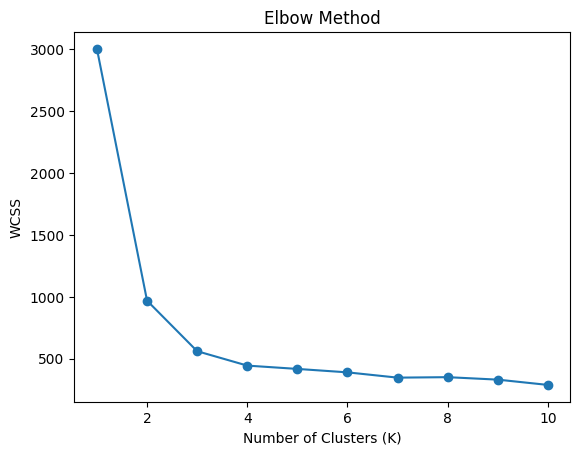

In [6]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The optimal K is chosen where the WCSS starts decreasing slowly. This point forms an "elbow" shape. Based on the plot, K = X is selected.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["cluster"] = clusters

In [8]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0: Young customers with low spending and few visits
Cluster 1: High spenders who visit frequently
Cluster 2: Infrequent visitors with medium spending

In [9]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [10]:
print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


In [11]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1", "PC2"]
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 represents features like spending and basket size (high loadings)
PC2 represents visit frequency and recency

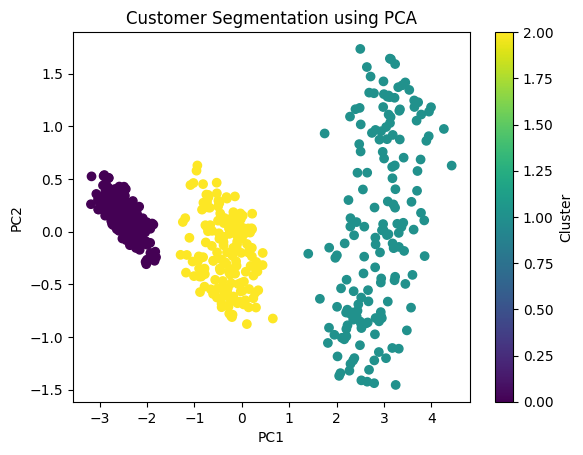

In [12]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df["cluster"])
plt.title("Customer Segmentation using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()